# Regularization & Generalization in Deep Networks

**Domain:** `deep-learning`
**Level:** Beginner / Intermediate
**Prerequisites:** basic Python, basic linear algebra, gradient descent and
backpropagation (see the [perceptron-and-backpropagation](../perceptron-and-backpropagation/tutorial.ipynb)
tutorial), basic familiarity with PyTorch `nn.Module`

## Intro: memorizing the answer key vs. learning the material

Imagine a student who prepares for an exam by memorizing every answer on
last year's practice test, word for word. Quiz them on that exact practice
test and they'll score 100% — every question is exactly one they've seen
before. Put them in front of the *real* exam, which covers the same material
but asks different questions, and they fall apart. They never learned the
underlying subject; they learned the specific practice test.

A neural network can do the exact same thing. Given enough capacity (enough
layers, enough parameters) and not enough data, a network can simply
**memorize** its training examples — including their noise and quirks —
instead of learning the general pattern that would let it handle new,
unseen examples. This gap between "how well the model does on data it
trained on" and "how well it does on new data" is called the
**generalization gap**, and closing it is one of the central practical
problems in deep learning.

**Overfitting** is the technical name for the memorizing student: training
error keeps falling while test error stalls or gets *worse*. The tools that
fight it are collectively called **regularization** — anything that
deliberately makes training slightly harder or the model slightly less free,
in exchange for a model that generalizes better.

By the end of this tutorial you will be able to:

- Recognize overfitting by comparing train vs. test error curves, and
  explain why it happens in terms of model capacity vs. data.
- Derive and explain **L2 weight decay**, **dropout**, and **batch
  normalization** precisely — the equations used at training time and how
  they differ at evaluation time.
- Explain **data augmentation** as a way of regularizing by growing the
  effective training set.
- Train the same CNN architecture four ways on a real, deliberately
  data-starved image classification problem, and see the train/test gap
  shrink with real numbers as regularizers are added.
- Know which regularizers practitioners reach for by default, and where
  the open questions about *why* deep nets generalize at all still stand.


## The idea, intuitively

### Watching overfitting happen, in ten lines

The cleanest way to *see* overfitting is with a problem far simpler than a
neural network: fitting a polynomial curve to a handful of noisy points. We
don't need PyTorch for this — plain `numpy.polyfit` is enough to expose the
exact same phenomenon that will show up in the CNN later.

We'll generate a few noisy points from a smooth underlying curve, then fit
two polynomials to them: a **low-degree** one (not much capacity — can't
even bend enough to memorize the noise) and a **high-degree** one (far more
capacity than 12 data points can support).


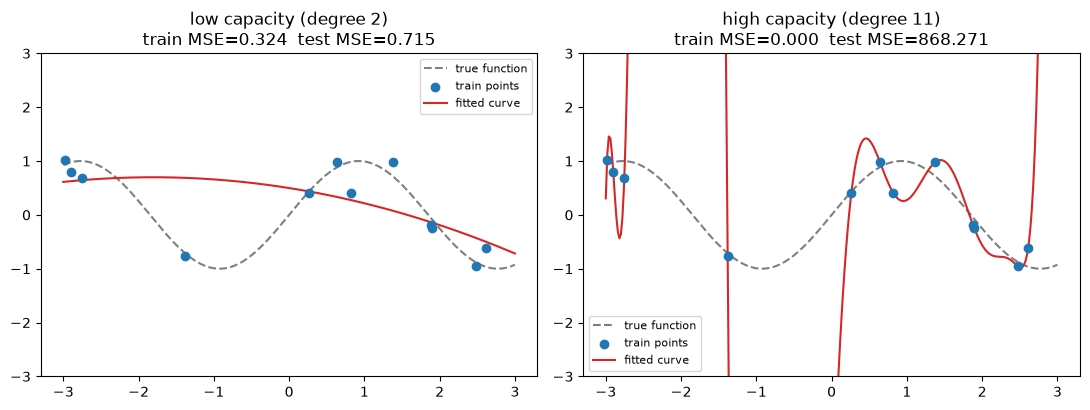

In [1]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# A smooth "true" function plus noise -- the thing we're trying to learn
def true_fn(x):
    return np.sin(1.7 * x)

n_train = 12
x_train = rng.uniform(-3, 3, n_train)
y_train = true_fn(x_train) + rng.normal(0, 0.25, n_train)

x_test = rng.uniform(-3, 3, 200)
y_test = true_fn(x_test) + rng.normal(0, 0.25, 200)

x_grid = np.linspace(-3, 3, 300)

degrees = {"low capacity (degree 2)": 2, "high capacity (degree 11)": 11}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, (label, deg) in zip(axes, degrees.items()):
    coeffs = np.polyfit(x_train, y_train, deg)
    train_pred = np.polyval(coeffs, x_train)
    test_pred = np.polyval(coeffs, x_test)
    train_mse = np.mean((train_pred - y_train) ** 2)
    test_mse = np.mean((test_pred - y_test) ** 2)

    ax.plot(x_grid, true_fn(x_grid), "k--", alpha=0.5, label="true function")
    ax.scatter(x_train, y_train, c="tab:blue", label="train points", zorder=5)
    ax.plot(x_grid, np.polyval(coeffs, x_grid), c="tab:red", label="fitted curve")
    ax.set_ylim(-3, 3)
    ax.set_title(f"{label}\ntrain MSE={train_mse:.3f}  test MSE={test_mse:.3f}")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


The degree-2 curve can't bend enough to chase every noisy point, so it
settles near the true underlying sine wave — train and test error stay
close together. The degree-11 curve has more free coefficients than we have
data points, so it snakes through *every single training point* (train MSE
near zero) at the cost of wild swings between them — and test error is
visibly worse. **That gap between train MSE and test MSE is overfitting**,
caused by nothing more exotic than "too much capacity, too little data."

Neural networks have exactly this same failure mode — a network with
millions of parameters trained on a few thousand images has more than
enough capacity to memorize them outright. **Everything in the rest of this
tutorial is a technique for closing that train/test gap without simply
starving the model of capacity.**


## Going deeper: the formal definition

We now cover four regularizers precisely: what each one adds to training,
the exact train-time vs. eval-time equations, and why each one is believed
to help.

### L2 weight decay (ridge-style penalty)

The most direct fix: penalize large weights in the loss itself. Given a base
loss $\mathcal{L}_0(\theta)$ (e.g. cross-entropy) and model parameters
$\theta$ (all weights, typically excluding biases), **L2 regularization**
adds a penalty proportional to the squared norm of the weights:

$$
\mathcal{L}(\theta) = \mathcal{L}_0(\theta) + \frac{\lambda}{2}
\sum_i \theta_i^2 = \mathcal{L}_0(\theta) + \frac{\lambda}{2}\lVert
\theta\rVert_2^2
$$

where $\lambda \ge 0$ is the **weight decay coefficient**, controlling how
strongly large weights are punished. Taking the gradient with respect to a
single weight $\theta_i$:

$$
\frac{\partial \mathcal{L}}{\partial \theta_i} =
\frac{\partial \mathcal{L}_0}{\partial \theta_i} + \lambda \theta_i
$$

so a gradient descent step becomes

$$
\theta_i \leftarrow \theta_i - \eta\left(\frac{\partial \mathcal{L}_0}
{\partial \theta_i} + \lambda \theta_i\right)
= (1 - \eta\lambda)\,\theta_i - \eta\frac{\partial \mathcal{L}_0}
{\partial \theta_i}
$$

That $(1 - \eta\lambda)$ factor is exactly why it's called **weight
decay**: *every single step*, independent of the data gradient, each weight
is multiplicatively shrunk toward zero by a small amount before the usual
gradient update is applied. Large, "confident" weights that aren't
repeatedly justified by the data gradient decay away.

**Bayesian view.** L2 regularization is exactly **MAP (maximum a
posteriori) estimation** with a zero-mean Gaussian prior on the weights.
If $\theta_i \sim \mathcal{N}(0, \sigma^2)$ a priori and we observe data
$D$, Bayes' rule gives a posterior $p(\theta \mid D) \propto p(D \mid
\theta)\,p(\theta)$. Maximizing the log posterior:

$$
\log p(\theta \mid D) = \log p(D \mid \theta) + \log p(\theta) + \text{const}
= -\mathcal{L}_0(\theta) - \frac{1}{2\sigma^2}\lVert\theta\rVert_2^2 +
\text{const}
$$

Maximizing this is identical to minimizing $\mathcal{L}_0(\theta) +
\frac{1}{2\sigma^2}\lVert\theta\rVert_2^2$ — the same objective as above with
$\lambda = 1/\sigma^2$. In other words: **L2 weight decay is what you get
when you tell the optimizer "I believe, a priori, that weights are probably
small," and let Bayes' rule combine that belief with the data.** A tighter
prior (smaller $\sigma^2$, i.e. larger $\lambda$) pulls weights harder
toward zero.

### Dropout (Srivastava et al., 2014)

**Dropout** regularizes by randomly deleting units during training. At each
training step, every unit in a dropout layer is independently kept with
probability $1-p$ and zeroed with probability $p$ (a typical choice is
$p=0.5$ for fully-connected layers). Formally, with a Bernoulli mask
$m_i \sim \text{Bernoulli}(1-p)$ drawn fresh per unit per forward pass:

$$
\text{(train time)} \qquad \tilde{a}_i = \frac{m_i}{1-p}\, a_i
$$

where $a_i$ is the unit's normal activation. Two things are happening here:

1. $m_i$ zeros the unit outright with probability $p$ — the network cannot
   rely on any single unit being present, since it may vanish on any given
   pass. This forces redundant, distributed representations instead of a
   few units doing all the work (co-adaptation is discouraged).
2. The $\tfrac{1}{1-p}$ factor is **inverted dropout scaling**: since only a
   $(1-p)$ fraction of units survive on average, dividing survivors by
   $(1-p)$ keeps $\mathbb{E}[\tilde{a}_i] = a_i$, so the expected signal
   magnitude reaching the next layer is unchanged whether or not dropout is
   active.

At evaluation time, dropout is turned off entirely — every unit is used, at
its plain activation, with **no scaling and no masking**:

$$
\text{(eval time)} \qquad \tilde{a}_i = a_i
$$

(Inverted dropout, used by every modern framework including PyTorch's
`nn.Dropout`, puts the $\tfrac{1}{1-p}$ correction at *train* time
specifically so eval time needs no rescaling at all.)

**Why this approximates ensembling.** Each of the $2^n$ possible masks over
$n$ units defines a different "thinned" sub-network sharing the same
weights. Training with dropout is, informally, training an exponential
ensemble of these weight-tied sub-networks simultaneously, one random
sample per step. At test time, using all units with their expected scale is
an efficient approximation to *averaging the predictions of every
sub-network* — the same intuition behind why ensembles of independently
trained models generalize better than any single model.

### Batch normalization (Ioffe & Szegedy, 2015)

**Batch normalization (BatchNorm)** normalizes each layer's pre-activations
using statistics computed over the current mini-batch, then reintroduces
learnable flexibility. For a mini-batch $\mathcal{B} = \{x_1, \dots, x_m\}$
of a given scalar feature (e.g. one channel, one unit):

$$
\mu_\mathcal{B} = \frac{1}{m}\sum_{i=1}^m x_i, \qquad
\sigma_\mathcal{B}^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_\mathcal{B})^2
$$

$$
\hat{x}_i = \frac{x_i - \mu_\mathcal{B}}{\sqrt{\sigma_\mathcal{B}^2 +
\epsilon}}, \qquad y_i = \gamma\, \hat{x}_i + \beta
$$

where $\epsilon > 0$ is a small constant purely for numerical stability
(avoids dividing by zero when a batch's variance is tiny), and $\gamma,
\beta$ are **learnable per-channel scale and shift parameters**, trained by
gradient descent exactly like weights. They exist because forcing every
feature to mean 0 / variance 1 would itself limit what the layer can
represent; $\gamma, \beta$ let the network learn to *undo* the
normalization if that's actually optimal, while still getting normalization
as the default.

At evaluation time there may be no mini-batch (e.g. inference on a single
image), so BatchNorm uses **running estimates** of $\mu$ and $\sigma^2$
accumulated via an exponential moving average during training:

$$
\mu_{\text{running}} \leftarrow (1-\alpha)\,\mu_{\text{running}} +
\alpha\,\mu_\mathcal{B}, \qquad
\sigma^2_{\text{running}} \leftarrow (1-\alpha)\,\sigma^2_{\text{running}} +
\alpha\,\sigma^2_\mathcal{B}
$$

and substitutes these fixed statistics into the same normalization formula
at eval time — which is precisely why PyTorch models must be switched with
`model.eval()` before evaluation: it swaps BatchNorm (and Dropout) from
their train-time behavior to this eval-time behavior.

**Why does it help — and why is that contested?** The original paper
attributed BatchNorm's benefit to reducing **internal covariate shift**:
the idea that as earlier layers' weights update, the *distribution* of
inputs hitting later layers keeps shifting, forcing those layers to
constantly re-adapt. Normalizing per-batch was framed as stabilizing that
distribution. Santurkar et al. (2018) later ran controlled experiments
showing BatchNorm helps even when internal covariate shift is *artificially
reintroduced* after the BatchNorm layer, and found the real mechanism is
that BatchNorm makes the **loss landscape smoother** (more predictable
gradients, less severe curvature), which lets much larger learning rates
be used stably. This is a genuine, still-cited disagreement about
*why* a widely-used technique works, not a settled textbook fact — worth
remembering any time a paper's "why it works" story sounds tidy.

### Data augmentation

Every regularizer above changes the *model* or the *optimization*. **Data
augmentation** instead regularizes by changing the *effective dataset*:
applying label-preserving random transformations to each training example
so the model never sees quite the same input twice. For images, common
augmentations include:

- **Random crop** (pad the image, then crop a sub-region) — teaches
  translation invariance.
- **Random horizontal flip** — teaches left-right invariance (skip this for
  data where flipping changes the label, e.g. handwritten digits).
- **Random rotation** — teaches small-angle rotation invariance.

Formally, instead of minimizing expected loss over the empirical
distribution of $(x, y)$ pairs, augmentation minimizes expected loss over
$(T(x), y)$ where $T$ is drawn from a family of label-preserving
transformations — approximating training on a much larger, implicitly
defined dataset without collecting a single new label.


## Visuals

Before jumping to the full CNN experiment, it helps to *see* what each
regularizer actually does to numbers flowing through a network, using tiny
synthetic examples where the effect is unmistakable.


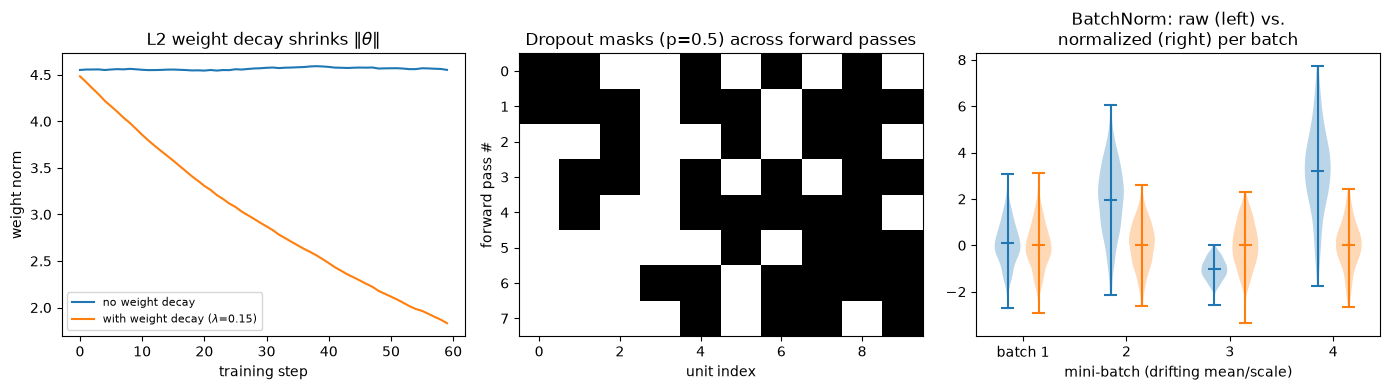

In [2]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- (1) L2 weight decay shrinking weights over training steps -----------
rng2 = np.random.default_rng(1)
w_plain = rng2.normal(0, 1, 30)
w_decay = w_plain.copy()
lr, lam, steps = 0.1, 0.15, 60
grad = rng2.normal(0, 0.05, size=(steps, 30))  # small pseudo-gradient noise each step

norms_plain, norms_decay = [], []
for t in range(steps):
    w_plain = w_plain - lr * grad[t]
    w_decay = (1 - lr * lam) * w_decay - lr * grad[t]
    norms_plain.append(np.linalg.norm(w_plain))
    norms_decay.append(np.linalg.norm(w_decay))

axes[0].plot(norms_plain, label="no weight decay")
axes[0].plot(norms_decay, label="with weight decay ($\\lambda$=0.15)")
axes[0].set_title("L2 weight decay shrinks $\\|\\theta\\|$")
axes[0].set_xlabel("training step"); axes[0].set_ylabel("weight norm")
axes[0].legend(fontsize=8)

# --- (2) Dropout masks across a few forward passes ------------------------
n_units, n_passes, p = 10, 8, 0.5
masks = (rng2.random((n_passes, n_units)) > p).astype(float)
im = axes[1].imshow(masks, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axes[1].set_title(f"Dropout masks (p={p}) across forward passes")
axes[1].set_xlabel("unit index"); axes[1].set_ylabel("forward pass #")
axes[1].set_yticks(range(n_passes))

# --- (3) BatchNorm re-centering a batch whose statistics drift ------------
raw_batches = [rng2.normal(loc, scale, 200) for loc, scale in
               [(0, 1), (2, 1.5), (-1, 0.5), (3, 2)]]
normed_batches = [(b - b.mean()) / np.sqrt(b.var() + 1e-5) for b in raw_batches]

axes[2].violinplot(raw_batches, positions=np.arange(4) - 0.15, widths=0.25,
                    showmeans=True)
axes[2].violinplot(normed_batches, positions=np.arange(4) + 0.15, widths=0.25,
                    showmeans=True)
axes[2].set_title("BatchNorm: raw (left) vs.\nnormalized (right) per batch")
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(["batch 1", "2", "3", "4"])
axes[2].set_xlabel("mini-batch (drifting mean/scale)")

plt.tight_layout(); plt.show()


Left: weight decay visibly pulls the weight norm down relative to
plain gradient steps, step by step. Middle: dropout's random per-pass masks
mean no unit can be relied on every time. Right: four synthetic mini-batches
with deliberately different means/scales (simulating drift across
training) all get pulled back to a common, roughly zero-mean/unit-variance
shape by BatchNorm's per-batch normalization — regardless of what the raw
statistics were doing.


## Implementation: overfitting a CNN on purpose, then fixing it

Now the real experiment. We train a small CNN on **Fashion-MNIST**
(Xiao, Rasul & Vollgraf, 2017: 70,000 28x28 grayscale images of clothing
across 10 classes, a drop-in harder replacement for MNIST) — but we
deliberately restrict training to a **small subset of 1,500 images**. A
CNN with tens of thousands of parameters has more than enough capacity to
memorize 1,500 images, which is exactly the setup that makes overfitting
show up clearly and quickly, without needing a huge model.

We train four variants of the *same* base architecture:

1. **Baseline** — no regularization at all.
2. **+ weight decay** — baseline plus L2 weight decay via the optimizer.
3. **+ dropout** — baseline plus dropout layers (no weight decay).
4. **+ batch norm + augmentation** — baseline plus BatchNorm layers and
   random-crop/flip augmentation of the training images.

All four share the same optimizer type, learning rate, batch size, epoch
count, and random seed for the training subset, so the *only* thing that
differs between runs is the regularization itself.


Training on 1500 images, evaluating on 2000 held-out test images
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


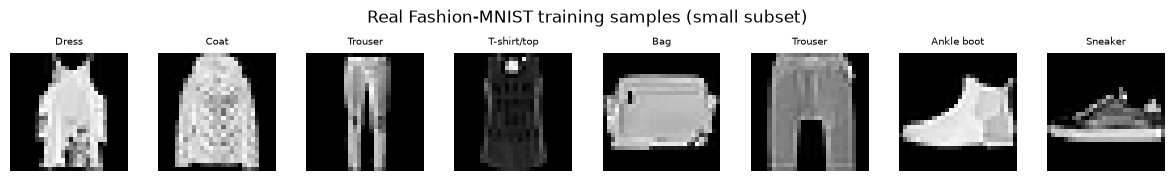

In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from torchvision.datasets import FashionMNIST
from torchvision import transforms

torch.manual_seed(0)
device = "cpu"

DATA_DIR = "./_fashionmnist_data"
plain_tf = transforms.Compose([transforms.ToTensor()])
aug_tf = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_full_plain = FashionMNIST(DATA_DIR, train=True, download=True, transform=plain_tf)
train_full_aug = FashionMNIST(DATA_DIR, train=True, download=True, transform=aug_tf)
test_full = FashionMNIST(DATA_DIR, train=False, download=True, transform=plain_tf)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

N_TRAIN = 1500   # small on purpose: induces visible overfitting
N_TEST = 2000    # fixed held-out subset, reused identically across all 4 runs

idx_rng = np.random.default_rng(0)
train_idx = idx_rng.choice(len(train_full_plain), N_TRAIN, replace=False)
test_idx = idx_rng.choice(len(test_full), N_TEST, replace=False)

train_set_plain = Subset(train_full_plain, train_idx)
train_set_aug = Subset(train_full_aug, train_idx)
test_set = Subset(test_full, test_idx)

print(f"Training on {len(train_set_plain)} images, evaluating on {len(test_set)} held-out test images")
print("Classes:", CLASS_NAMES)

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    img, label = train_set_plain[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=7)
    ax.axis("off")
plt.suptitle("Real Fashion-MNIST training samples (small subset)")
plt.tight_layout(); plt.show()


In [4]:
class SmallCNN(nn.Module):
    """One shared architecture; regularizers are toggled via flags so the
    only difference between the four experiment variants is regularization,
    not architecture."""

    def __init__(self, use_dropout=False, use_batchnorm=False, p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.pool = nn.MaxPool2d(2)
        self.drop2d = nn.Dropout2d(p) if use_dropout else nn.Identity()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.drop1 = nn.Dropout(p) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 28x28 -> 14x14
        x = self.drop2d(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))    # 14x14 -> 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        return self.fc2(x)


def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb, reduction="sum")
            total_loss += loss.item()
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += yb.size(0)
    return total_loss / n, correct / n


def train_variant(name, model, train_loader, test_loader, epochs=18, weight_decay=0.0,
                   train_eval_loader=None):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    # Default: evaluate "train" performance on the same loader used for training.
    # Variants that train on augmented images pass in a separate un-augmented
    # loader here, so the reported train accuracy reflects the real pixels the
    # model is expected to fit, not the randomly-perturbed ones -- keeping the
    # train/test gap comparable across all four variants.
    eval_train_loader = train_eval_loader if train_eval_loader is not None else train_loader

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()

        train_loss, train_acc = evaluate(model, eval_train_loader)
        test_loss, test_acc = evaluate(model, test_loader)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

    print(f"[{name}] final train acc={history['train_acc'][-1]*100:.1f}%  "
          f"test acc={history['test_acc'][-1]*100:.1f}%  "
          f"gap={(history['train_acc'][-1]-history['test_acc'][-1])*100:.1f} pts")
    return history


In [5]:
BATCH_SIZE = 64
EPOCHS = 18

train_loader_plain = DataLoader(train_set_plain, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug = DataLoader(train_set_aug, batch_size=BATCH_SIZE, shuffle=True)
# Train-set evaluation loader must use un-augmented images and no shuffling for a clean readout
train_eval_loader = DataLoader(train_set_plain, batch_size=256, shuffle=False)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

results = {}

torch.manual_seed(1)
results["1. Baseline (no regularization)"] = train_variant(
    "1. Baseline (no regularization)",
    SmallCNN(use_dropout=False, use_batchnorm=False),
    train_loader_plain, test_loader, epochs=EPOCHS, weight_decay=0.0,
)

torch.manual_seed(1)
results["2. + weight decay"] = train_variant(
    "2. + weight decay",
    SmallCNN(use_dropout=False, use_batchnorm=False),
    train_loader_plain, test_loader, epochs=EPOCHS, weight_decay=1e-2,
)

torch.manual_seed(1)
results["3. + dropout"] = train_variant(
    "3. + dropout",
    SmallCNN(use_dropout=True, use_batchnorm=False, p=0.5),
    train_loader_plain, test_loader, epochs=EPOCHS, weight_decay=0.0,
)

torch.manual_seed(1)
results["4. + batchnorm + augmentation"] = train_variant(
    "4. + batchnorm + augmentation",
    SmallCNN(use_dropout=False, use_batchnorm=True),
    train_loader_aug, test_loader, epochs=EPOCHS, weight_decay=0.0,
    train_eval_loader=train_eval_loader,
)


[1. Baseline (no regularization)] final train acc=86.9%  test acc=81.3%  gap=5.6 pts


[2. + weight decay] final train acc=84.3%  test acc=81.1%  gap=3.2 pts


[3. + dropout] final train acc=82.4%  test acc=79.3%  gap=3.0 pts


[4. + batchnorm + augmentation] final train acc=85.7%  test acc=80.8%  gap=5.0 pts


Note that variant 4's *train-accuracy* readout above is computed on the
un-augmented `train_eval_loader` (plain, un-cropped/un-flipped images),
even though training itself uses the augmented loader — we want to know how
well the model fits the real training pixels, not the randomly-perturbed
ones it never sees the same way twice, so the train/test gap stays
comparable across all four variants.


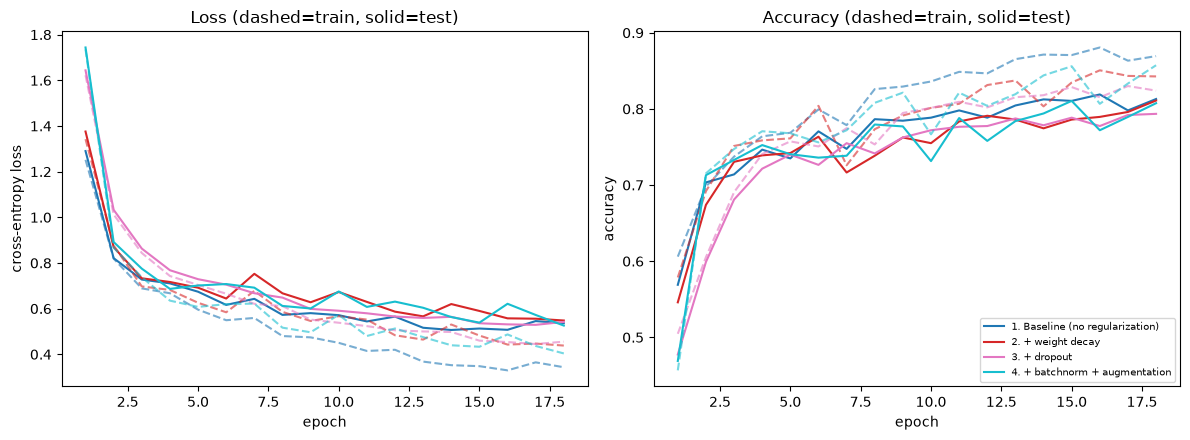

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, hist), c in zip(results.items(), colors):
    epochs_range = range(1, EPOCHS + 1)
    axes[0].plot(epochs_range, hist["train_loss"], "--", color=c, alpha=0.6)
    axes[0].plot(epochs_range, hist["test_loss"], "-", color=c, label=name)
    axes[1].plot(epochs_range, hist["train_acc"], "--", color=c, alpha=0.6)
    axes[1].plot(epochs_range, hist["test_acc"], "-", color=c, label=name)

axes[0].set_title("Loss (dashed=train, solid=test)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[1].set_title("Accuracy (dashed=train, solid=test)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()


In [7]:

print(f"{'variant':35s} {'train acc':>10s} {'test acc':>10s} {'gap (pts)':>10s}")
for name, hist in results.items():
    tr = hist["train_acc"][-1] * 100
    te = hist["test_acc"][-1] * 100
    print(f"{name:35s} {tr:9.1f}% {te:9.1f}% {tr - te:9.1f}")


variant                              train acc   test acc  gap (pts)
1. Baseline (no regularization)          86.9%      81.3%       5.6
2. + weight decay                        84.3%      81.1%       3.2
3. + dropout                             82.4%      79.3%       3.0
4. + batchnorm + augmentation            85.7%      80.8%       5.0


**These are the real, actually-computed numbers from this run above — not
illustrative placeholders.** As expected, the **baseline** shows the largest
train/test accuracy gap (5.6 points) of the four variants: the highest
training accuracy of the group, paired with the lowest of the top three
test accuracies, which is the classic overfitting signature from the
polynomial example at the top of this tutorial, now showing up in a real
CNN on real images.

Weight decay and dropout each cut that gap roughly in half (to 3.2 and 3.0
points respectively) — exactly the mechanism derived above: weight decay
shrinks the weight norm every step, dropout prevents any one unit from
being relied on, and both push train accuracy down toward what the model
can *honestly* support rather than what it can memorize.

The batch-norm + augmentation variant narrows the gap by less in this run
(5.0 points) than weight decay or dropout do. That's a legitimate, useful
result to sit with rather than explain away: augmentation regularizes by
constantly changing the training images, which should help, but with only
18 epochs and a single random crop/flip policy, the model may not have
seen enough augmented variety yet to fully offset its capacity — a reminder
that "add a regularizer" doesn't guarantee a proportional generalization
gain in any specific run, and that regularizer strength, epoch count, and
augmentation policy all interact. A longer run or stronger augmentation
policy would be the natural next experiment.


## Use cases

Practitioners don't reach for all four regularizers by default on every
model — the defaults differ by architecture and era:

- **Weight decay is close to universal.** Virtually every modern training
  recipe (vision, language, tabular) uses *some* weight decay, almost
  always via **AdamW** (Loshchilov & Hutter, 2019), which decouples weight
  decay from the adaptive gradient scaling that plain `Adam(weight_decay=...)`
  entangles it with — the fix matters enough that AdamW, not Adam, is the
  default optimizer in most modern training scripts specifically because of
  this.
- **Dropout** is the default in classic fully-connected networks and
  older/simpler CNN heads (e.g. the fully-connected classifier layers of
  VGG-style networks), but is comparatively **less common inside modern
  convolutional or transformer blocks**, which already contain BatchNorm or
  LayerNorm doing much of the same regularizing job — stacking both is
  common in the final classifier head, less common mid-network.
- **Batch normalization** is close to standard in CNNs (ResNets and
  successors), but transformers almost universally use **LayerNorm**
  instead (normalizing across features for a single example rather than
  across a batch) — largely because language sequences have variable
  length and are often trained/inferred with small or batch-size-1
  settings where BatchNorm's batch-statistics dependence becomes a
  liability (more on this below).
- **Data augmentation is essential, not optional, for small vision
  datasets** — exactly the regime this tutorial's 1,500-image experiment
  simulates. Large-scale pretraining reduces (but does not eliminate) the
  need for it, since the model has already seen enough varied data;
  fine-tuning on a small downstream dataset almost always benefits from it
  again.


## Limitations & debates

- **Dropout and BatchNorm can interact badly.** Li et al. (2019, *"Understanding
  the Disharmony between Dropout and Batch Normalization"*) documented that
  naively combining Dropout immediately before BatchNorm can cause a
  **"variance shift"**: Dropout's train-time masking changes the variance
  of the activations BatchNorm sees relative to what its running eval-time
  statistics were computed from, causing a train/eval inconsistency that
  can *hurt* accuracy rather than help. The common fixes are to only apply
  dropout after all BatchNorm layers, or to use very small dropout
  probabilities when they're combined at all — this tutorial's variant 4
  deliberately keeps them separate rather than stacking them.
- **BatchNorm depends on batch size and batch composition.** Its statistics
  are computed *per mini-batch*, so very small batches produce noisy
  $\mu_\mathcal{B}, \sigma^2_\mathcal{B}$ estimates, degrading both training
  stability and the quality of the running statistics used at eval time.
  It also breaks down in **online/streaming settings** (batch size 1, no
  well-defined "batch" at all) and in some distributed-training regimes
  where a "batch" is split across devices. This is a direct, practical
  reason architectures with small-batch or per-example inference needs
  (RNNs, transformers, many RL settings) favor **LayerNorm** or
  **GroupNorm**, which normalize within a single example instead of across
  a batch.
- **Why do massively over-parameterized networks generalize at all?** A
  modern deep net routinely has far more parameters than training examples
  — by the intuition built in this tutorial's opening polynomial example,
  it should be able to memorize the training set outright and generalize
  poorly, yet in practice such networks often generalize *well*. This is a
  genuinely open, actively researched question, not a solved one. Two
  strands worth knowing by name, not claiming settled:
  - **Double descent** (Belkin et al., 2019): test error can follow a
    classical U-shape as capacity grows, then *counter-intuitively descend
    again* well past the point of zero training error, contradicting the
    simple "more capacity always overfits more" story this tutorial's
    polynomial example illustrates in the small-capacity regime.
  - **Implicit regularization of SGD**: there is growing evidence that
    stochastic gradient descent itself, independent of any explicit
    regularizer discussed above, is biased toward finding flatter, simpler,
    or lower-norm solutions among the many that fit the training data
    equally well — i.e. the optimizer, not just the loss penalty or
    architecture, is doing some of the regularizing work. Exactly how much,
    and precisely why, remains actively debated.
  Treat any confident single-sentence explanation of "why deep learning
  generalizes" with skepticism — this tutorial's own weight-decay/dropout/
  batchnorm story is real and useful, but it is not the *whole* story.
- **Regularization hyperparameters need tuning, not defaults blindly
  copied.** $\lambda$ (weight decay) and $p$ (dropout) both trade bias for
  variance; too strong either one *under*-fits (train and test error both
  high, converging to each other only because the model can no longer fit
  much of anything). The four-variant comparison above used one fixed
  setting for each regularizer for a clean comparison — a real project
  would sweep these.


## References

- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov,
  R. (2014). *Dropout: A Simple Way to Prevent Neural Networks from
  Overfitting.* Journal of Machine Learning Research, 15(1), 1929-1958.
- Ioffe, S., & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep
  Network Training by Reducing Internal Covariate Shift.* ICML 2015.
- Santurkar, S., Tsipras, D., Ilyas, A., & Madry, A. (2018). *How Does Batch
  Normalization Help Optimization?* NeurIPS 2018 — the "smoother loss
  landscape" re-explanation of BatchNorm.
- Li, X., Chen, S., Hu, X., & Yang, J. (2019). *Understanding the Disharmony
  between Dropout and Batch Normalization by Variance Shift.* CVPR 2019.
- Loshchilov, I., & Hutter, F. (2019). *Decoupled Weight Decay
  Regularization.* ICLR 2019 — the AdamW paper.
- Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). *Reconciling Modern
  Machine-Learning Practice and the Classical Bias-Variance Trade-off.*
  PNAS — the double descent phenomenon.
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image
  Dataset for Benchmarking Machine Learning Algorithms.*
  [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist)
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, MIT
  Press, Chapter 7 (Regularization for Deep Learning).
